In [1]:
# Imports

import tensorflow as tf
from tensorflow import keras, GradientTape
from keras import layers, Sequential, Model
from keras.datasets import mnist
from keras.layers import Dense
from tensorflow import cast, float32
import numpy as np
from tensorflow import losses

import matplotlib.pyplot as plt # type: ignore
import time

In [2]:
class GA_Weights():
    def __init__(self,
                 loss_fn,
                 eval_model,
                 pop_size=20,
                 generations=50,
                 crossover_rate=0.9,
                 mutation_rate=0.2,
                 mutation_std = 0.05,
                 alpha = 0.3,
                 subset_size = 256,
                 elitism = True):

        self.loss_fn = loss_fn
        self.eval_model = eval_model
        self.pop_size = pop_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.mutation_std = mutation_std
        self.alpha = alpha
        self.subset_size = subset_size
        self.elitism = elitism

        self.history = {
            "best":[],
            "avg":[],
            "std":[],
            "diversity":[]
        }

    def fitness_fn(self, individual, x, y):
        self.eval_model.set_weights(individual)
        y_pred = self.eval_model(x, training=False)
        return self.loss_fn(y, y_pred)

    def population_diversity(self, population):
        flat = [
            tf.concat(
                [tf.reshape(w, [-1]), tf.reshape(b, [-1])],
                axis=0
            )
            for w, b in population
        ]
        stack = tf.stack(flat)
        return tf.reduce_mean(tf.math.reduce_std(stack, axis=0))

    # Mutacion del indivudo seleccionado desde el crossover
    def mutate(self, individual):
        W, b = individual
        if tf.random.uniform(()) < self.mutation_rate:
            W = W + tf.random.normal(
                shape=tf.shape(W),
                stddev=self.mutation_std,
                dtype=W.dtype
            )
            b = b + tf.random.normal(
                shape=tf.shape(b),
                stddev=self.mutation_std,
                dtype=b.dtype
            )
        return [W, b]

    def crossover(self, parent_a, parent_b):
        Wa, ba = parent_a
        Wb, bb = parent_b

        def blend(a, b):
            min_v = tf.minimum(a, b)
            max_v = tf.maximum(a, b)
            d = max_v - min_v
            low = min_v - self.alpha * d
            high = max_v - self.alpha * d

            return tf.random.uniform(
                shape=tf.shape(a),
                minval=low,
                maxval=high,
                dtype=a.dtype
            )
        child_W = blend(Wa, Wb)
        chidl_b = blend(ba, bb)

        return [child_W, chidl_b]

    # Seleccion de un solo individuo por torneo
    def tournament(self, pop, scores, k=15):
        idx = tf.random.shuffle(tf.range(len(pop)))[:k]
        selected_scores = tf.gather(scores, idx)
        best = idx[tf.argmin(selected_scores)]
        return pop[int(best)]

    def run(self, x, y, best_weight=None):
        start_time = time.time()
        global_best = float("inf")
        global_best_weights = None

        base_W  = self.eval_model.get_weights()
        population = []

        if best_weight is not None:
            population.append(best_weight)

        while len(population) < self.pop_size:
            population.append([
                base_W[0] + tf.random.normal(base_W[0].shape) * 0.1,
                base_W[1] + tf.random.normal(base_W[1].shape) * 0.1,
            ])
        for gen in range(self.generations):
            idx = tf.random.shuffle(tf.range(len(x)))[:self.subset_size]
            x_batch = tf.gather(x, idx)
            y_batch = tf.gather(y, idx)

            fitness_scores = tf.stack([
                self.fitness_fn(ind, x_batch, y_batch)
                for ind in population
            ])

            # Metricas
            best = tf.reduce_min(fitness_scores)
            avg = tf.reduce_mean(fitness_scores)
            std = tf.math.reduce_std(fitness_scores)
            diversity = self.population_diversity(population)

            self.history["best"].append(float(best))
            self.history["avg"].append(float(avg))
            self.history["std"].append(float(std))
            self.history["diversity"].append(float(diversity))

            best_idx = int(tf.argmin(fitness_scores))
            if float(best) < global_best:
                global_best = float(best)
                global_best_weights = population[best_idx]

            new_population = []

            if self.elitism:
                new_population.append(population[best_idx])

            while len(new_population) < self.pop_size:
                parent_a = self.tournament(population, fitness_scores)
                parent_b = self.tournament(population, fitness_scores)

                if tf.random.uniform(()) < self.crossover_rate:
                    child = self.crossover(parent_a, parent_b)
                else:
                    child = parent_a

                child = self.mutate(child)
                new_population.append(child)

            population = new_population
        total_time = time.time() - start_time
        return global_best_weights, global_best, total_time



    def call_best_weights_GA(self, x, y, best_weight = []):
        population = []
        idx = tf.random.shuffle(tf.range(len(x)))[: self.subset_size]
        x = tf.gather(x, idx)
        y = tf.gather(y, idx)
        base_W = self.eval_model.get_weights()
        if best_weight is not None:
            base_W = best_weight
        while len(population) < self.pop_size:
            population.append([
                    base_W[0] + tf.random.normal(base_W[0].shape) * 0.1,
                    base_W[1] + tf.random.normal(base_W[1].shape) * 0.1,
                ])

        for _ in range(self.generations):
            fitness_scores = tf.stack([self.fitness_fn(ind, x, y) for ind in population])

            if self.current_best < self.global_best:
                self.global_best_weights = population[self.best_index]
            new_population = [population[int(tf.argmin(fitness_scores))]]
            while len(new_population) < self.pop_size:
                parent_a = self.tournament(population, fitness_scores)
                parent_b = self.tournament(population, fitness_scores)

                child = self.crossover(parent_a, parent_b) if tf.random.uniform(()) < self.crossover_rate else parent_a
                child = self.mutate(child)
                new_population.append(child)

            population = new_population

        return population[int(tf.argmin(fitness_scores))]


In [3]:
class myModel():
    def __init__(self, feature_extractor, classifier, batch_size=32):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = classifier
        self.batch_size = batch_size

        self.optimizer = keras.optimizers.Adam()
        self.loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
        self.acc_metric = keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.best_weights = None
        self.GA_Weights = GA_Weights(
            loss_fn=self.loss_fn,
            eval_model=self.classifier,
            pop_size=30,
            generations=100,
            alpha=0.8,
            mutation_std=0.09,
            mutation_rate=0.8,
            crossover_rate=0.9
            )

    def features_extractor_mlp(self, x):
        feats = self.feature_extractor(x, training=True)
        return self.classifier(feats, training=False)

    def create_dataset(self, x, y):
        return tf.data.Dataset.from_tensor_slices((x, y)).batch(self.batch_size)

    def train_epoch(self, x, y, num_epochs):
        dataset = self.create_dataset(x, y)
        for epoch in range(num_epochs):
            for xb, yd in dataset:
                with GradientTape() as tape:
                    logits = self.features_extractor_mlp(xb)
                    loss = self.loss_fn(yd, logits)
                gradients = tape.gradient(loss, self.feature_extractor.trainable_variables)
                self.optimizer.apply_gradients(zip(gradients, self.feature_extractor.trainable_variables))

            features = self.feature_extractor(x, training=False)
            self.classifier(features, training=True)
            self.best_weights, _, total_time = self.GA_Weights.run(features, y, self.best_weights)
            self.classifier.set_weights(self.best_weights)

            preds = self.classifier(features, training=True)
            self.acc_metric.update_state(y, preds)

            acc = float(self.acc_metric.result())
            self.acc_metric.reset_state()
            print(f"Epoch {epoch+1} | loss={loss:.4f} acc={acc:.4f}")
        return float(loss), acc


    def predict(self, x):
        out = []
        for xb in x:
            outX = []
            feats = self.feature_extractor(xb, training=True)
            logits = self.classifier(feats, training=False)
            outX.append(tf.argmax(logits, axis=1))
        return tf.concat(out, axis=0)


In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Clases pero en palabras para que se vea mas chido
class_names = ['cero','uno','dos','tres','cuatro','cinco','seis','siete','ocho','nueve']


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
cnn = Sequential([
        layers.Input(shape = (28, 28, 1)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten()
])

mlp = Dense(10, activation='softmax', name='classifier')

In [6]:
model = myModel(cnn, mlp, 32)
model.train_epoch(x_test, y_test, 10)

Epoch 1 | loss=0.4024 acc=0.3709
Epoch 2 | loss=0.0605 acc=0.8851
Epoch 3 | loss=0.0374 acc=0.9153
Epoch 4 | loss=0.0268 acc=0.9334
Epoch 5 | loss=0.0222 acc=0.9433
Epoch 6 | loss=0.0170 acc=0.9489
Epoch 7 | loss=0.0179 acc=0.9532
Epoch 8 | loss=0.0137 acc=0.9586
Epoch 9 | loss=0.0127 acc=0.9628
Epoch 10 | loss=0.0106 acc=0.9655


(0.010570484213531017, 0.965499997138977)

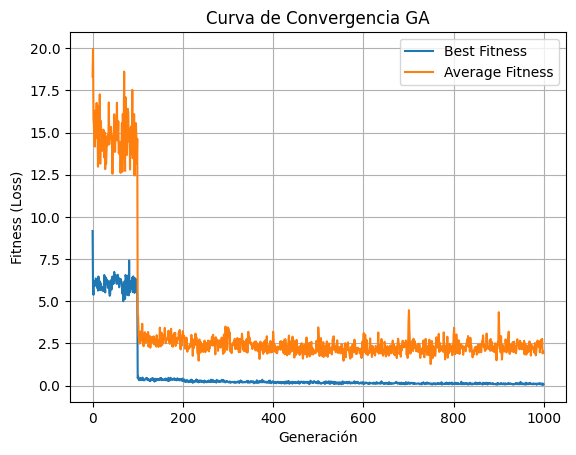

In [7]:
ga = model.GA_Weights.history
plt.figure()
plt.plot(ga["best"])
plt.plot(ga["avg"])

plt.xlabel("Generación")
plt.ylabel("Fitness (Loss)")
plt.title("Curva de Convergencia GA")

plt.legend(["Best Fitness", "Average Fitness"])
plt.grid(True)

plt.show()

In [8]:
from sklearn.preprocessing import OneHotEncoder # type: ignore

# Queria hacer esto con tensorflow pero preferi hacerlo con
# sklearn porque se me hizo sencillo y aun no entendi bien como
# lo hace tensorflow
enc = OneHotEncoder()
# Sacamos las imagenes y labels para pruebas
predict_x = x_train[0:100]
y_true =  y_train[0:100]

# Train labels
y_true = y_true[..., np.newaxis]
transformed = enc.fit_transform(y_true)
train_labels_encoded = transformed.toarray()

In [9]:
fe = model.feature_extractor.predict(predict_x)
y_pred = model.classifier(fe, training=False)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_classification(y_true, y_pred, output_prefix="model_eval"):

    # =========================
    # Preparación de etiquetas
    # =========================
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_flat = y_true.reshape(-1)

    num_classes = y_pred.shape[1]

    # =========================
    # Métricas principales
    # =========================
    accuracy = accuracy_score(y_true_flat, y_pred_classes)
    precision_macro = precision_score(y_true_flat, y_pred_classes, average="macro")
    recall_macro = recall_score(y_true_flat, y_pred_classes, average="macro")
    f1_macro = f1_score(y_true_flat, y_pred_classes, average="macro")

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    loss = loss_fn(y_true, y_pred).numpy()

    top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, num_classes))
    top5.update_state(y_true, y_pred)
    top5_acc = top5.result().numpy()

    # =========================
    # Guardar métricas en CSV
    # =========================
    metrics_dict = {
        "Accuracy": accuracy,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Loss": loss,
        "Top5_accuracy": top5_acc
    }

    df_metrics = pd.DataFrame([metrics_dict])
    df_metrics.to_csv(f"{output_prefix}_metrics.csv", index=False)

    # =========================
    # Classification Report
    # =========================
    report = classification_report(y_true_flat, y_pred_classes, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f"{output_prefix}_classification_report.csv")

    # =========================
    # Matriz de Confusión
    # =========================
    cm = confusion_matrix(y_true_flat, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix.svg", format="svg")
    plt.close()

    # =========================
    # Matriz Normalizada
    # =========================
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix_normalized.svg", format="svg")
    plt.close()

    plt.figure(figsize=(10,4))

    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(predict_x[i])
        plt.title(f"True: {y_true_flat[i]}\nPred: {y_pred_classes[i]}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_ten_images.svg", format="svg")
    plt.close()

    print("Evaluación completada y archivos guardados.")
    print(metrics_dict)

    return metrics_dict


In [11]:
fe = model.feature_extractor.predict(x_test)
y_pred = model.classifier(fe, training=False).numpy()

evaluate_classification(y_test, y_pred, output_prefix="FE_GA_MLP_model")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Evaluación completada y archivos guardados.
{'Accuracy': 0.9655, 'Precision_macro': 0.9675802537778775, 'Recall_macro': 0.9652505944440077, 'F1_macro': 0.9654602000920447, 'Loss': np.float32(0.10486433), 'Top5_accuracy': np.float32(0.9993)}


{'Accuracy': 0.9655,
 'Precision_macro': 0.9675802537778775,
 'Recall_macro': 0.9652505944440077,
 'F1_macro': 0.9654602000920447,
 'Loss': np.float32(0.10486433),
 'Top5_accuracy': np.float32(0.9993)}

In [17]:
model.feature_extractor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
mlp = model.classifier
print(mlp.get_config())        # Configuración
print(mlp.get_weights())       # Pesos
print(mlp.count_params())      # Número de parámetros

{'name': 'classifier', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 10, 'activation': 'softmax', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}
[array([[-0.12556376,  0.06225152, -0.11621634, ..., -0.19467236,
         0.03490628, -0.16584879],
       [-0.06435043, -0.3028434 , -0.09493078, ..., -0.02089625,
        -0.04357602, -0.23698016],
       [-0.36975327, -0.3266807 , -0.19279128, ...,  0.02072722,
        -0.05498511, -0.16964361],
       ...,
       [-0.02393458,  0.04210891, -0.0452605 , ...,  0.03086002,
         0.03969166,  0.06321996],
       [-0.195